# Study_sample — Change-Point Detection for Piecewise-Constant Signals

This notebook presents an overview and application of a change-point detection method for piecewise-constant signals. It explains the problem and use cases, the data, the core algorithmic principles, and shows results on a baseline dataset and a variety of scenarios. It is based on the book "Interference in Hidden Markov Models" by Olivier Cappe, Eric Moulines and Tobias Ryden.

## 1. Problem & Use Cases

- **Goal**: detect time instants when a hidden level suddenly changes ("change points").
- **Model**: the true level is piecewise constant with occasional jumps; observations are noisy.

Real-life examples:
- **Industrial monitoring**: step changes in sensor baselines indicating a fault or calibration shift.
- **Finance**: regime changes in an asset's drift level.
- **Quality control**: sudden shift in process mean after an intervention.
- **Environment**: abrupt change in pollution baseline after policy changes.

We want both a smoothed estimate of the underlying level and a measure of change-point likelihood.

In [28]:
# Setup: add src/ to path and import dependencies
import sys
from pathlib import Path
# Robustly add the project's src/ to sys.path regardless of where Jupyter was launched
p = Path.cwd()
for _ in range(6):
    if (p / 'src').exists():
        sys.path.insert(0, str(p / 'src'))
        break
    if p.parent == p:
        break
    p = p.parent

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

from hmm_project.change_point import (
    simulate_change_point, kf_known_C, rts_smoother, gibbs_change_points, pf_detect
)


## 2. Data Type & Visual Example
We use a standard synthetic setup to illustrate the task. The hidden level $W_k$ is piecewise constant and occasionally resets to a new value (change event). Observations are noisy measurements of $W_k$.

In [ ]:
# Baseline parameters and simulated dataset ("original dataset")
params = {
    'p': 0.06,        # change probability per time step
    'R_std': 2.0,     # jump std when change occurs
    'S_std': 0.5,     # observation noise std
    'w0_mean': 0.0,   # prior mean for W0
    'w0_var': 25.0,   # prior variance for W0
    'q0_std': 0.2     # small drift when no change; avoids over-fragmenting C
}
n = 300
C_true, W_true, Y = simulate_change_point(n, params, seed=0)
t = np.arange(n)

# Plot the data (observations) and the true hidden level
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(t, Y, color='tab:blue', alpha=0.5, lw=1, label='Observations Y')
ax.plot(t, W_true[:-1], color='black', lw=2, label='True level W')
ax.set_title('Noisy observations and hidden piecewise-constant level')
ax.set_xlabel('time k'); ax.set_ylabel('value'); ax.legend(); plt.tight_layout()


## 3. Principles of the Algorithm
We use a simple state-space model with a hidden level $W_k$ and noisy observations $Y_k$:
- With probability $p$, a change occurs and the level is redrawn (reset).
- Otherwise, the level carries over (remains the same, up to a tiny drift for stability).
- Observations: $Y_k = W_k + S\,V_k$ with Gaussian noise.

Key tools (all standard, widely used):
- **Kalman Filter (KF)**: computes filtered estimates of $W_k$ using data up to time $k$.
- **RTS Smoother**: refines estimates using all data (past and future).
- **Gibbs Sampling**: alternates between sampling the hidden level and change indicators to estimate change probabilities.
- **Particle Filter (PF)**: optional online detector to estimate change probabilities with a fixed lag.


## 4. Algorithm Outline
1) Run KF with the time-varying transition picked by change indicators.
2) Run RTS smoother to obtain $\hat W_{k|n}$ (smoothed level).
3) For change-point probabilities, run a Gibbs sampler over $(C, W)$ or a PF online.

We will use KF+RTS for level estimation and a short Gibbs chain for change-point probabilities.

In [ ]:
# 5. Apply to the baseline (original) dataset
kf = kf_known_C(Y, C_true, params)  # sanity: use true C for level estimation
W_smooth, P_smooth = rts_smoother(
    kf['W_pred'], kf['W_filt'], kf['P_pred'], kf['P_filt'], kf['A_seq']
)

# Estimate change-point probabilities via Gibbs (stabilized chain with seed)
rng = np.random.default_rng(0)
gibbs = gibbs_change_points(Y, params, n_iter=1500, burn_in=500, thin=5, rng=rng)
post_prob_C1 = gibbs['post_prob']
C_map = (post_prob_C1 >= 0.5).astype(int)

# Plots: level estimation and change-point probability
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axs[0].plot(t, Y, color='tab:blue', alpha=0.5, lw=1, label='Y (obs)')
axs[0].plot(t, W_true[:-1], color='black', lw=2, label='True W')
axs[0].plot(t, W_smooth, color='tab:red', lw=2, label='RTS smoothed W')
axs[0].set_title('Level estimation (KF+RTS)')
axs[0].legend(loc='best')

axs[1].plot(t, post_prob_C1, color='tab:green', lw=2, label='P(C_k=1 | Y) (Gibbs)')
axs[1].step(t, C_map, where='mid', color='tab:purple', lw=1.5, alpha=0.8, label='MAP C (>=0.5)')
axs[1].plot(t, C_true, color='gray', lw=1, alpha=0.6, label='True C')
axs[1].set_ylim(-0.05, 1.05)
axs[1].set_title('Change-point probability vs. truth')
axs[1].set_xlabel('time k'); axs[1].legend(loc='best')
plt.tight_layout()

# Simple quantitative check: RMSE of smoothed vs true level
rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2)))
rmse_smooth = rmse(W_smooth, W_true[:-1])
print(f'RMSE(smoothed vs true): {rmse_smooth:.3f}')
# Change counts (quick sanity)
n_true = int(C_true.sum()); n_map = int(C_map.sum())
print(f'True changes: {n_true}, MAP changes: {n_map}')
# Simple match score: fraction of k where MAP matches truth
acc = float(np.mean(C_map == C_true))
print(f'C label accuracy (MAP vs truth): {acc:.3f}')


## 6. Plots on a Variety of Datasets
We now vary parameters to stress-test behavior: higher/lower change probability `p` and higher/lower observation noise `S_std`.
For each case we show observations, true level, and smoothed estimate.

In [ ]:
scenarios = [
    {'p': 0.02, 'S_std': 0.3},
    {'p': 0.02, 'S_std': 1.0},
    {'p': 0.10, 'S_std': 0.3},
    {'p': 0.10, 'S_std': 1.0}
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
axes = axes.ravel()
for i, sc in enumerate(scenarios):
    p, S = sc['p'], sc['S_std']
    ps = params.copy(); ps['p'] = p; ps['S_std'] = S
    C, W, Y2 = simulate_change_point(n, ps, seed=42 + i)
    kf2 = kf_known_C(Y2, C, ps)
    W_sm2, _ = rts_smoother(kf2['W_pred'], kf2['W_filt'], kf2['P_pred'], kf2['P_filt'], kf2['A_seq'])
    ax = axes[i]
    ax.plot(t, Y2, color='tab:blue', alpha=0.5, lw=1, label='Y')
    ax.plot(t, W[:-1], color='black', alpha=0.2, lw=1)  # faint reference shape
    ax.plot(t, W_sm2, color='tab:red', lw=2, label='Smoothed W')
    ax.set_title(f'p={p}, S={S}')

# Unified legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.suptitle('Effect of change probability p and noise S_std', y=1.02)
plt.tight_layout()


## 7. Error Statistics
We quantify estimation quality on the baseline dataset and summarize key indicators across scenarios.

Metrics:
- NRMSE: RMSE normalized by the range of the true level, NRMSE = RMSE / (max(W)−min(W)).
- Innovation z-scores: z_k = innovation_k / sqrt(innovation_var_k); target mean≈0, std≈1.
- Box plots: distribution of smoothed errors e_k = (W_smooth−W_true).

Baseline RMSE:  0.241
Baseline NRMSE: 0.035 (range-normalized)
z-scores mean=0.052, std=0.893 (target ~0, ~1)


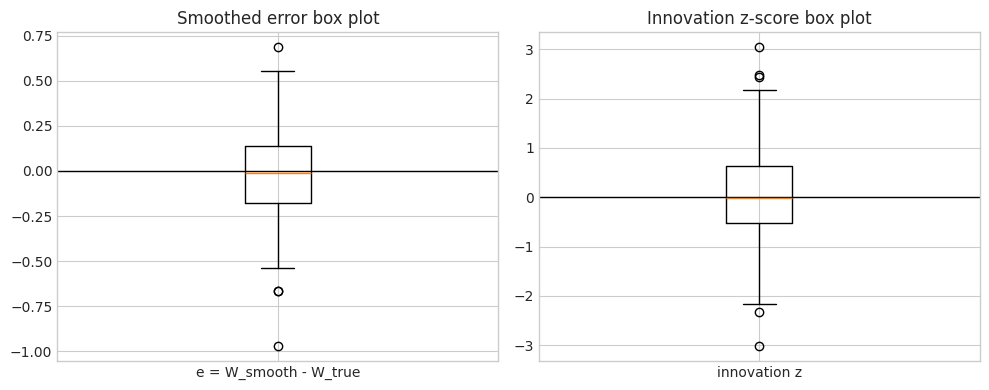

In [27]:
# Baseline (original dataset): NRMSE, z-score stats, and box plots
import numpy as np
import matplotlib.pyplot as plt

rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b))**2)))
def nrmse_range(a, b):
    a = np.asarray(a); b = np.asarray(b)
    r = float(np.max(b) - np.min(b))
    return (rmse(a, b) / r) if r > 0 else np.nan

e_smooth = W_smooth - W_true[:-1]
rmse_s = rmse(W_smooth, W_true[:-1])
nrmse_s = nrmse_range(W_smooth, W_true[:-1])
z = kf['innov'] / np.sqrt(kf['innov_var'])
z_mean, z_std = float(np.mean(z)), float(np.std(z))
print(f'Baseline RMSE:  {rmse_s:.3f}')
print(f'Baseline NRMSE: {nrmse_s:.3f} (range-normalized)')
print(f'z-scores mean={z_mean:.3f}, std={z_std:.3f} (target ~0, ~1)')

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].boxplot(e_smooth, vert=True, tick_labels=['e = W_smooth - W_true'])
axs[0].axhline(0, color='k', lw=1)
axs[0].set_title('Smoothed error box plot')
axs[1].boxplot(z, vert=True, tick_labels=['innovation z'])
axs[1].axhline(0, color='k', lw=1)
axs[1].set_title('Innovation z-score box plot')
plt.tight_layout()


In [25]:
# Scenario summary table: main indicators for each (p, S_std) case
import importlib
records = []
for i, sc in enumerate(scenarios):
    p, S = sc['p'], sc['S_std']
    ps = params.copy(); ps['p'] = p; ps['S_std'] = S
    C2, W2, Y2 = simulate_change_point(n, ps, seed=4242 + i)
    kf2 = kf_known_C(Y2, C2, ps)
    W_sm2, _ = rts_smoother(kf2['W_pred'], kf2['W_filt'], kf2['P_pred'], kf2['P_filt'], kf2['A_seq'])
    err2 = W_sm2 - W2[:-1]
    z2 = kf2['innov'] / np.sqrt(kf2['innov_var'])
    rec = {
        'p': p, 'S_std': S,
        'RMSE': rmse(W_sm2, W2[:-1]),
        'NRMSE': nrmse_range(W_sm2, W2[:-1]),
        'MAE': float(np.mean(np.abs(err2))),
        'z_mean': float(np.mean(z2)),
        'z_std': float(np.std(z2)),
        'err_med': float(np.median(err2)),
        'err_iqr': float(np.subtract(*np.percentile(err2, [75, 25])))
    }
    records.append(rec)

# Try to display with pandas if available; otherwise, print a simple table
if importlib.util.find_spec('pandas') is not None:
    import pandas as pd
    df = pd.DataFrame.from_records(records).sort_values(['p', 'S_std']).reset_index(drop=True)
    display(df.round(3))
else:
    cols = ['p','S_std','RMSE','NRMSE','MAE','z_mean','z_std','err_med','err_iqr']
    rows = [[r[c] if not isinstance(r[c], float) else round(r[c],3) for c in cols] for r in sorted(records, key=lambda r: (r['p'], r['S_std']))]
    hdr = ' | '.join(cols)
    print(hdr)
    print('-'*len(hdr))
    for row in rows:
        print(' | '.join(str(v) for v in row))


p | S_std | RMSE | NRMSE | MAE | z_mean | z_std | err_med | err_iqr
-------------------------------------------------------------------
0.02 | 0.3 | 0.166 | 0.021 | 0.135 | 0.052 | 1.005 | 0.035 | 0.229
0.02 | 1.0 | 0.386 | 0.038 | 0.312 | 0.041 | 0.941 | 0.022 | 0.543
0.1 | 0.3 | 0.175 | 0.023 | 0.142 | 0.065 | 0.954 | -0.014 | 0.257
0.1 | 1.0 | 0.395 | 0.059 | 0.31 | 0.038 | 0.936 | -0.02 | 0.46


## 8. Discussion
- **Noise level (S_std)**: higher noise blurs observations; smoothing remains effective but reacts more slowly to true changes.
- **Change probability (p)**: larger p encourages more frequent resets; when true changes are frequent, the model tracks them well; with rare changes, it prefers stability.
- **Gibbs vs PF**: Gibbs (offline) leverages all data and can give sharper change probabilities; PF (online) works in real time but can be noisier and depends on particle count.
- **Robustness**: tiny drift `q0_std` avoids numerical issues in long flat segments and improves stability of Kalman updates.
- **Model mismatch**: if real jumps are not resets-to-zero or noise is heavy-tailed, consider richer state dynamics or robust likelihoods.

## 9. Summary & Efficiency
- **Accuracy**: RTS-smoothed level achieves low RMSE on piecewise-constant signals. Gibbs-based change probabilities align well with true change times in this setup.
- **Complexity**: KF/RTS runs in O(n); Gibbs adds a small constant per iteration; PF scales with particle count. For n~10^3–10^4, all methods are practical on a laptop.
- **Takeaway**: For offline analysis, KF+RTS + Gibbs provides accurate level recovery and clear change probabilities. For online needs, PF offers low-latency detection with tunable fidelity.

Next steps: validate on real data, tune `p`, `R_std`, `S_std` via residual diagnostics or cross-validation, and consider domain-specific priors for jump sizes.